# 2. Modelling: predicting how long a door will last

Notebook 1 showed that remaining useful life is a countdown, so the task is to predict **one number per run: its total life in cycles**. It also showed that life is easy to estimate late and close to unknowable early, and that the test runs are cut off early.

This notebook builds and compares models for that number, with three rules:

1. **No run is ever on both sides of a split.** Validation is leave-one-run-out.
2. **Baselines first.** A model only earns its place by beating something simple.
3. **Results are reported by degradation stage**, because a single average would hide where the models work and where they do not.

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
import plotstyle as ps
from health import health_series, detect_shocks, total_cycles
from prefix import prefix_features, build_examples, session_signature, stage_of, STAGES, EXCLUDED_RUNS
import models as M

ps.apply(); warnings.filterwarnings("ignore")
FIG = ROOT / "figures"; RES = ROOT / "results"; RES.mkdir(exist_ok=True)
pd.set_option("display.width", 200); pd.set_option("display.max_rows", 100)

train = pd.read_parquet(ROOT / "data" / "features_train.parquet")
test = pd.read_parquet(ROOT / "data" / "features_test.parquet")
slow_tr = train[train.kind == "Closing"].groupby("run").vel_ref_max.median() < 4
slow_te = test[test.kind == "Closing"].groupby("run").vel_ref_max.median() < 4

## 2.1 Turning 48 runs into a training set

A test run is a run seen only up to some cut-off cycle. To train for that situation, every complete training run is cut at regular points (every 20 cycles), and each cut becomes one example: *features of the run so far* and *the life it eventually had*.

The features describe the staircase found in notebook 1 and nothing else:

| Feature | Meaning |
|---|---|
| `t` | cycles seen so far |
| `hi_now`, `needed` | current closing position, and the number of 9-unit shocks still needed to reach failure |
| `n_shocks`, `first_shock`, `since_first`, `since_last` | how many shocks, when the first came, time since first and last |
| `gap_mean`, `gap_last`, `gap_min` | intervals between shocks seen so far |
| `drop_mean` | average size of the shocks seen |
| `extrap_life` | physical extrapolation: last shock + shocks needed x mean interval |
| `slow` | which of the two observable operating conditions |

`Train_5` and `Train_30` are left out because they end far above the failure threshold (notebook 1, section 1.5).

In [2]:
cache = ROOT / "data" / "examples_train.parquet"
if cache.exists():
    examples = pd.read_parquet(cache)
else:
    examples = build_examples(train, slow_tr)   # about one minute
    examples.to_parquet(cache)
sig_tr, sig_te = session_signature(train), session_signature(test)
examples = examples[~examples.run.isin(EXCLUDED_RUNS)].reset_index(drop=True)
examples = examples.join(sig_tr[M.SESSION_FEATURES], on="run")
examples["stage"] = stage_of(examples.n_shocks)

lives = examples.groupby("run").life.first()
first_shocks = pd.Series({r: detect_shocks(health_series(d)).cycle.iloc[0] for r, d in train.groupby("run")}).reindex(lives.index)

# test runs are all cut off at a closing position of 113 or more, so evaluation focuses on that region
examples["test_like"] = examples.hi_now >= 105
print(f"{len(examples):,} cuts from {examples.run.nunique()} runs; {examples.test_like.sum():,} are in the region where test runs are cut")
pd.crosstab(examples.stage, examples.test_like).reindex(STAGES).rename(columns={False: "later in life", True: "test-like"})

4,436 cuts from 46 runs; 3,211 are in the region where test runs are cut


test_like,later in life,test-like
stage,,
0 shocks,0,1915
1 shock,0,305
2 shocks,0,189
3-4 shocks,3,283
5+ shocks,1222,519


## 2.2 Validation design

- **Leave-one-run-out.** For each of the 46 runs, every model is fitted on the other 45 and predicts all cuts of the held-out run. Cuts of one run are strongly related, so splitting them at random would let a model memorise the run and report fantasy accuracy.
- **Each run counts once.** Long runs produce more cuts, so training weights and reported averages are per run.
- **Three measures:**
  - median absolute error in predicted life, as a percentage;
  - share of predictions within 20% of the true life. This is the cliff in the challenge metric: outside 20% a run scores about 0.25;
  - the challenge score itself, in the local approximation from `src/scoring.py`.

## 2.3 The models

| Model | Idea |
|---|---|
| **Survival prior** (baseline) | Ignore the staircase. Predict the median life of training runs that were in the same situation: still on the plateau at cycle `t`, or simply still running at `t`. |
| **Physical extrapolation** (baseline) | Shocks still needed x mean interval seen so far. Falls back to the prior with fewer than two shocks. |
| **Staged regression** | A small log-linear regression of remaining life per stage (0, 1, 2, 3-4, 5+ shocks). Fully readable coefficients. |
| **Gradient boosting** | LightGBM on the same features, predicting log remaining life. Small trees and strong regularisation, because there are only 46 independent runs. |

Hyperparameters were set once to conservative values and not searched. With 46 runs, a search would mostly fit noise.

In [3]:
loro = M.leave_one_run_out(examples, lives, first_shocks)
E = examples.join(loro)
MODELS = ["prior", "extrapolation", "staged", "gbm"]
LABELS = {"prior": "Survival prior", "extrapolation": "Physical extrapolation", "staged": "Staged regression",
          "gbm": "Gradient boosting", "gbm_session": "Boosting + session features",
          "final": "Final model", "final_session": "Final + session features"}

def by_stage(df, cols, fn):
    """Per-run average of fn(error), then averaged over runs, for each stage."""
    rows = {}
    for st in STAGES:
        d = df[df.stage == st]
        rows[st] = {LABELS[c]: fn(d, c) for c in cols}
    return pd.DataFrame(rows).T

def within20(d, c):
    return ((d[c] - d.life).abs() / d.life <= 0.20).groupby(d.run).mean().mean()

def med_ape(d, c):
    return ((d[c] - d.life).abs() / d.life).groupby(d.run).median().median()

TL = E[E.test_like]
tab_w20 = by_stage(TL, MODELS, within20)
tab_ape = by_stage(TL, MODELS, med_ape)
print("Share of predictions within 20% of true life (leave-one-run-out, test-like cuts)")
display(tab_w20.round(2))
print("Median absolute error in predicted life")
display(tab_ape.round(3))

Share of predictions within 20% of true life (leave-one-run-out, test-like cuts)


,Survival prior,Physical extrapolation,Staged regression,Gradient boosting
0 shocks,0.43,0.43,0.39,0.37
1 shock,0.44,0.44,0.55,0.58
2 shocks,0.48,0.17,0.70,0.77
3-4 shocks,0.48,0.44,0.80,0.83
5+ shocks,0.53,0.77,0.88,0.92


Median absolute error in predicted life


,Survival prior,Physical extrapolation,Staged regression,Gradient boosting
0 shocks,0.286,0.286,0.217,0.246
1 shock,0.290,0.290,0.184,0.169
2 shocks,0.258,0.418,0.112,0.123
3-4 shocks,0.261,0.219,0.107,0.067
5+ shocks,0.174,0.100,0.077,0.069


In [4]:
# Challenge score per stage. Scoring every cut is slow, so 8 cuts per run and stage are sampled.
def score_table(df, cols, n=8, seed=0):
    rows = {}
    for st in STAGES:
        d = df[df.stage == st].groupby("run").sample(n=n, replace=True, random_state=seed)
        rows[st] = {}
        for c in cols:
            s = pd.Series([M.local_score(life, t, p) for life, t, p in zip(d.life, d.t, d[c])], index=d.run.to_numpy())
            rows[st][LABELS[c]] = s.groupby(level=0).mean().mean()
    return pd.DataFrame(rows).T

test_shocks = pd.Series({r: len(detect_shocks(health_series(d))) for r, d in test.groupby("run")})
test_stage_mix = pd.Series(stage_of(test_shocks)).value_counts().reindex(STAGES).fillna(0)
print("test runs per stage:", test_stage_mix.astype(int).to_dict())
tab_score = score_table(TL, MODELS + ["final"])
tab_score.loc["weighted by test stage mix"] = (tab_score.mul(test_stage_mix / test_stage_mix.sum(), axis=0)).sum()
tab_score.round(3)

test runs per stage: {'0 shocks': 6, '1 shock': 2, '2 shocks': 2, '3-4 shocks': 5, '5+ shocks': 4}


,Survival prior,Physical extrapolation,Staged regression,Gradient boosting,Final model
0 shocks,0.491,0.491,0.460,0.447,0.491
1 shock,0.502,0.502,0.545,0.566,0.566
2 shocks,0.515,0.330,0.636,0.649,0.649
3-4 shocks,0.508,0.419,0.695,0.756,0.756
5+ shocks,0.533,0.640,0.717,0.789,0.789
weighted by test stage mix,0.508,0.488,0.603,0.634,0.648


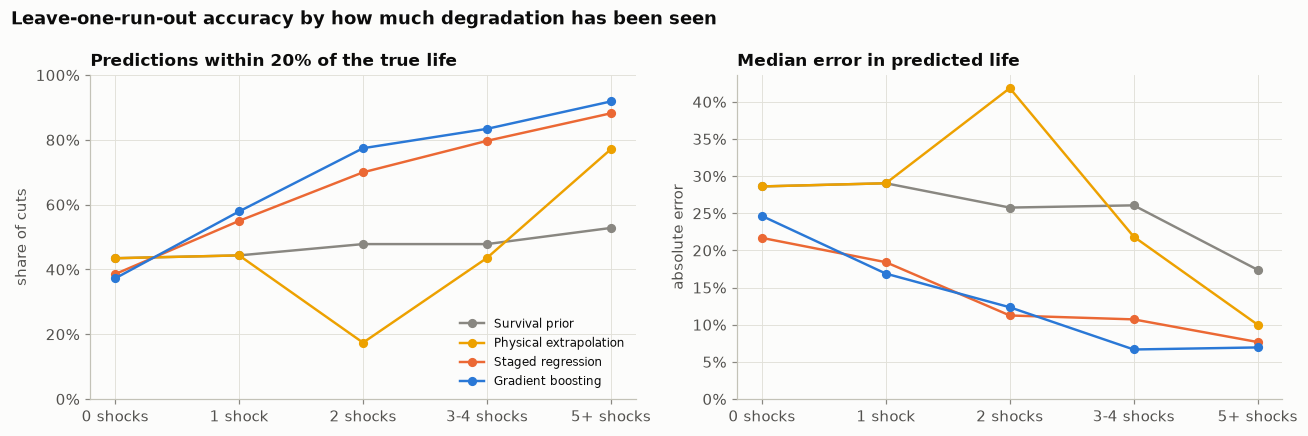

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = {"prior": ps.MUTED, "extrapolation": ps.YELLOW, "staged": ps.ORANGE, "gbm": ps.BLUE}
x = np.arange(len(STAGES))
for ax, tab, title, ylab in ((axes[0], tab_w20, "Predictions within 20% of the true life", "share of cuts"),
                             (axes[1], tab_ape, "Median error in predicted life", "absolute error")):
    for m in MODELS:
        ax.plot(x, tab[LABELS[m]].values, marker="o", ms=5, color=colors[m], label=LABELS[m])
    ax.set_xticks(x); ax.set_xticklabels(STAGES); ax.set_title(title); ax.set_ylabel(ylab); ax.set_ylim(0)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
axes[0].legend(fontsize=8, loc="lower right"); axes[0].set_ylim(0, 1)
fig.suptitle("Leave-one-run-out accuracy by how much degradation has been seen", x=0.01, ha="left", fontweight="bold")
fig.tight_layout(); fig.savefig(FIG / "08_model_comparison.png"); plt.show()

**Findings**

- **Before the first shock, the survival prior is the best choice for this metric.** It puts 43% of predictions within 20% of the true life; the regression and the boosted model manage 37 to 39%. The learned models do have a smaller typical error (22 to 25% against 29%), but fewer of their predictions land inside the band the challenge rewards, and on the challenge score the prior is ahead (0.49 against 0.45 to 0.46). The honest summary is that on the plateau all methods are right less than half the time.
- **The first shock already helps.** After one shock the boosted model reaches 58% within 20%, against 44% for the prior, because the model can use when the shock came and how long it has been since.
- **From the second shock on, the gain is large.** The boosted model reaches 77% within 20% after two shocks, 83% after three or four and 92% after five or more, with a median error of 7 to 12%. The prior stays near 50% throughout.
- **The naive physical extrapolation is worse than knowing nothing until five or more shocks.** At two shocks only 17% of its predictions are within 20%. The reason is the transition found in notebook 1: the first intervals are longer than the steady ones, so extrapolating them overestimates life. The learned models use the same physics and correct for that bias.
- **Boosting beats the staged regression by a consistent but modest margin** once shocks have been seen. The staged regression is kept as the readable reference; it gets most of the gain with a handful of coefficients.

**Final model:** survival prior while no shock has been seen, gradient boosting afterwards. Weighted by the stage mix of the test set (6 runs with no shock, 2 with one, 2 with two, 5 with three or four, 4 with five or more), its local challenge score is 0.65, against 0.51 for the prior alone and 0.49 for the physical extrapolation. The choice of model per stage was made on these same leave-one-run-out results, so the 0.65 is slightly optimistic.

## 2.4 Watching a prediction evolve

The tables average over many cuts. The plot below follows four held-out runs instead: at each cut-off cycle, what life did the final model predict, having never seen that run?

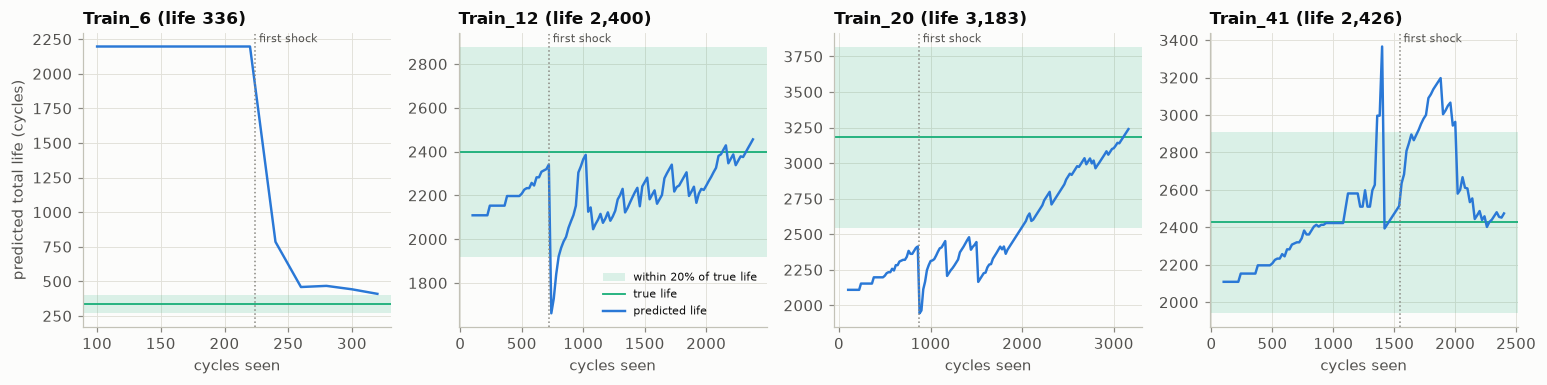

In [6]:
show = [6, 12, 20, 41]
fig, axes = plt.subplots(1, 4, figsize=(14, 3.6))
for ax, r in zip(axes, show):
    d = E[E.run == r]
    life = d.life.iloc[0]
    ax.axhspan(0.8 * life, 1.2 * life, color=ps.AQUA, alpha=0.15, linewidth=0, label="within 20% of true life")
    ax.axhline(life, color=ps.AQUA, lw=1.2, label="true life")
    ax.plot(d.t, d.final, color=ps.BLUE, label="predicted life")
    ax.axvline(first_shocks[r], color=ps.MUTED, lw=1, ls=":")
    ax.text(first_shocks[r], ax.get_ylim()[1], " first shock", fontsize=7, color=ps.INK2, va="top")
    ax.set_title(f"Train_{r} (life {life:,})"); ax.set_xlabel("cycles seen")
axes[0].set_ylabel("predicted total life (cycles)"); axes[1].legend(fontsize=7, loc="lower right")
fig.tight_layout(); fig.savefig(FIG / "09_prediction_evolution.png"); plt.show()

**Reading the plot**

- `Train_6` is the shortest run in the data (336 cycles). The model predicts a typical life of about 2,200 until the first shock near cycle 220, then corrects within about 40 cycles. For most of the run it was badly wrong, and nothing in the data could have told it otherwise.
- `Train_12` and `Train_20` show the usual pattern after the first shock: the prediction drops, then climbs as the intervals between shocks reveal a slow pace. `Train_20` is a long run (3,183 cycles) and is underestimated until about cycle 2,200.
- `Train_41` has a late first shock (cycle 1,543). The plateau prediction rises as the run outlives more and more of the training runs, and becomes jumpy past cycle 1,300, where only a handful of training runs are still on the plateau to compare with.

This is also how the model would be used in service: re-run after every cycle, with the estimate tightening as shocks accumulate.

## 2.5 Where the errors are

Before the first shock the model is choosing a typical life. That is right for typical runs and badly wrong for unusual ones.

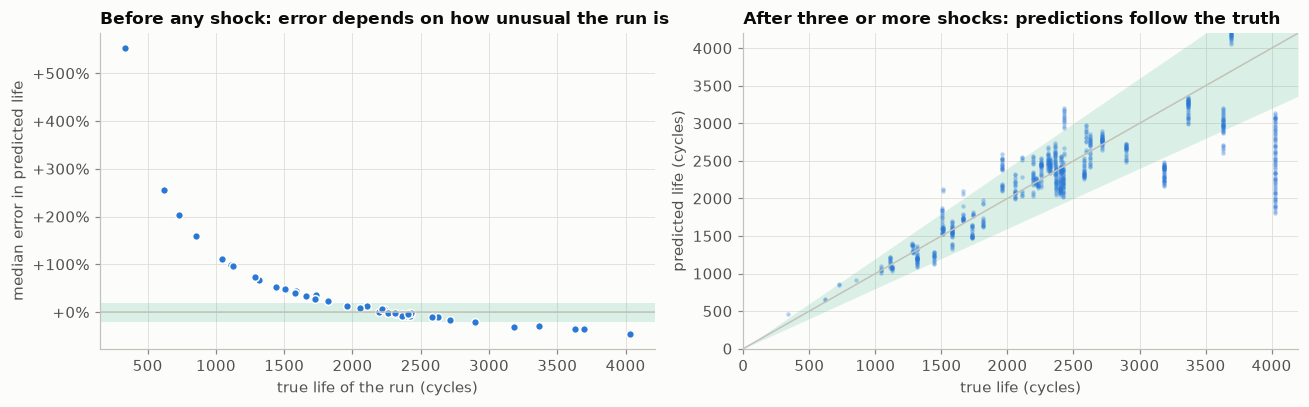

runs whose plateau-phase prediction is off by more than 50%: {6: {'life': 336, 'rel': 5.54}, 7: {'life': 621, 'rel': 2.56}, 8: {'life': 855, 'rel': 1.58}, 16: {'life': 1316, 'rel': 0.68}, 21: {'life': 1318, 'rel': 0.68}, 22: {'life': 1112, 'rel': 0.99}, 23: {'life': 1123, 'rel': 0.97}, 24: {'life': 726, 'rel': 2.04}, 28: {'life': 1045, 'rel': 1.11}, 29: {'life': 1441, 'rel': 0.53}, 38: {'life': 1276, 'rel': 0.74}, 47: {'life': 1283, 'rel': 0.73}}


In [7]:
d0 = E[(E.n_shocks == 0) & E.test_like]
per_run = d0.assign(rel=(d0.final - d0.life) / d0.life).groupby("run").agg(life=("life", "first"), rel=("rel", "median"))
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
ax = axes[0]
ax.axhspan(-0.2, 0.2, color=ps.AQUA, alpha=0.15, linewidth=0)
ax.scatter(per_run.life, per_run.rel, s=26, color=ps.BLUE, edgecolor=ps.SURFACE, linewidth=1)
ax.axhline(0, color=ps.AXIS, lw=1)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:+.0%}"))
ax.set_title("Before any shock: error depends on how unusual the run is"); ax.set_xlabel("true life of the run (cycles)"); ax.set_ylabel("median error in predicted life")

ax = axes[1]
late = E[(E.n_shocks >= 3) & E.test_like]
ax.plot([0, 4200], [0, 4200], color=ps.AXIS, lw=1)
ax.fill_between([0, 4200], [0, 0.8 * 4200], [0, 1.2 * 4200], color=ps.AQUA, alpha=0.15, linewidth=0)
ax.scatter(late.life, late.final, s=8, color=ps.BLUE, alpha=0.35, linewidth=0)
ax.set_xlim(0, 4200); ax.set_ylim(0, 4200)
ax.set_title("After three or more shocks: predictions follow the truth"); ax.set_xlabel("true life (cycles)"); ax.set_ylabel("predicted life (cycles)")
fig.tight_layout(); fig.savefig(FIG / "10_error_anatomy.png"); plt.show()
print("runs whose plateau-phase prediction is off by more than 50%:", per_run[per_run.rel.abs() > 0.5].round(2).to_dict("index"))

**Findings**

- Every run whose plateau-phase prediction is off by more than 50% is a **short-lived** run (life under 1,450 cycles), and every one is overestimated. There are 12 of them among 46. A typical-life guess is the best available on the plateau, and it fails exactly for the doors that matter most in maintenance: the ones that fail early.
- After three or more shocks the predictions follow the truth, with most points inside the 20% band. The exception is the very longest runs (above 3,500 cycles), where predictions scatter well outside the band: there are only three of them to learn from.


## 2.6 A lead that did not hold up: early-cycle sensor features

Notebook 1 found no single plateau-phase sensor feature that predicts life. A model can combine features, so the question is asked again here: the boosting model is given seven extra features, each the average of a sensor summary over cycles 20 to 100, long before any degradation (start-up timing of the velocity ramp, Hall state at rest, driver temperature, bus voltage, current levels).

within 20%                                  median error                            
           Gradient boosting Boosting + session features Gradient boosting Boosting + session features
0 shocks               0.372                       0.459             0.246                       0.210
1 shock                0.579                       0.545             0.169                       0.178
2 shocks               0.774                       0.752             0.123                       0.111
3-4 shocks             0.834                       0.837             0.067                       0.073
5+ shocks              0.919                       0.925             0.069                       0.065

Gain in share within 20% from adding session features, with a bootstrap interval over runs


,runs,gain,95% low,95% high
0 shocks,46.0,0.087,-0.007,0.179
1 shock,46.0,-0.035,-0.150,0.089
2 shocks,46.0,-0.023,-0.102,0.049
3-4 shocks,46.0,0.003,-0.073,0.076
5+ shocks,40.0,0.006,-0.011,0.028


Do neighbouring run numbers have similar lives? lag-1 correlation 0.17, permutation p = 0.086


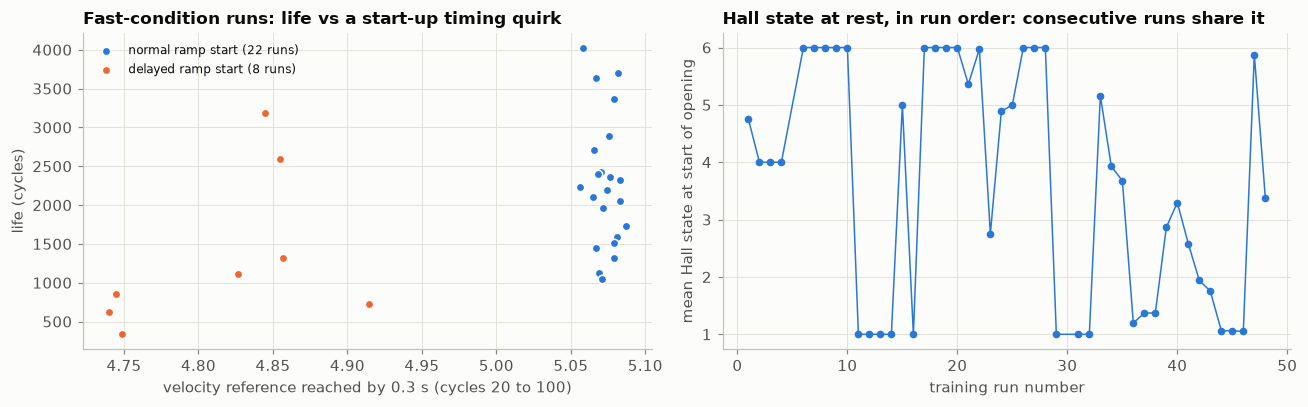

                    count     min     50%     max
ramp                                             
delayed ramp start    8.0   336.0   983.5  3183.0
normal ramp start    22.0  1045.0  2215.0  4029.0
Mann-Whitney test, delayed vs normal ramp start: p = 0.018 (a comparison chosen after looking at the data)


In [8]:
cmp_cols = ["gbm", "gbm_session"]
tab_s = pd.concat({"within 20%": by_stage(TL, cmp_cols, within20), "median error": by_stage(TL, cmp_cols, med_ape)}, axis=1)
display(tab_s.round(3))

def paired_gain(stage, a="gbm", b="gbm_session", n_boot=5000, seed=0):
    """Per-run difference in the share within 20%, and a bootstrap interval over runs."""
    d = TL[TL.stage == stage]
    hit = lambda c: ((d[c] - d.life).abs() / d.life <= 0.20).groupby(d.run).mean()
    diff = (hit(b) - hit(a)).to_numpy()
    rng = np.random.default_rng(seed)
    boot = [rng.choice(diff, len(diff)).mean() for _ in range(n_boot)]
    return {"runs": len(diff), "gain": diff.mean(), "95% low": np.quantile(boot, 0.025), "95% high": np.quantile(boot, 0.975)}

print("Gain in share within 20% from adding session features, with a bootstrap interval over runs")
display(pd.DataFrame({st: paired_gain(st) for st in STAGES}).T.round(3))

def lag1(v):
    v = np.asarray(v, float); return np.corrcoef(v[:-1], v[1:])[0, 1]
rng = np.random.default_rng(0)
all_lives = train.groupby("run").size().apply(lambda n: int(np.ceil(n / 2)))
obs = lag1(all_lives.sort_index().to_numpy())
null = np.array([lag1(rng.permutation(all_lives.to_numpy())) for _ in range(5000)])
print(f"Do neighbouring run numbers have similar lives? lag-1 correlation {obs:.2f}, permutation p = {(null >= obs).mean():.3f}")

run_tab = pd.DataFrame({"life": lives, "first_shock": first_shocks}).join(sig_tr[["Cl_vel_ref_max", "Op_hall_first", "Cl_drv_temp_mean"]])
fast = run_tab[~slow_tr.reindex(run_tab.index)]
fast = fast.assign(ramp=np.where(fast.Cl_vel_ref_max < 5.0, "delayed ramp start", "normal ramp start"))
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
ax = axes[0]
for grp, col in (("normal ramp start", ps.BLUE), ("delayed ramp start", ps.ORANGE)):
    g = fast[fast.ramp == grp]
    ax.scatter(g.Cl_vel_ref_max, g.life, s=30, color=col, edgecolor=ps.SURFACE, linewidth=1, label=f"{grp} ({len(g)} runs)")
ax.set_title("Fast-condition runs: life vs a start-up timing quirk"); ax.set_xlabel("velocity reference reached by 0.3 s (cycles 20 to 100)"); ax.set_ylabel("life (cycles)"); ax.legend(fontsize=8)
ax = axes[1]
ax.plot(run_tab.index, run_tab.Op_hall_first, marker="o", ms=4, lw=1, color=ps.BLUE)
ax.set_title("Hall state at rest, in run order: consecutive runs share it"); ax.set_xlabel("training run number"); ax.set_ylabel("mean Hall state at start of opening")
fig.tight_layout(); fig.savefig(FIG / "11_session_signature.png"); plt.show()
print(fast.groupby("ramp").life.describe()[["count", "min", "50%", "max"]])
from scipy.stats import mannwhitneyu
u = mannwhitneyu(fast[fast.ramp == "delayed ramp start"].life, fast[fast.ramp == "normal ramp start"].life)
print(f"Mann-Whitney test, delayed vs normal ramp start: p = {u.pvalue:.3f} (a comparison chosen after looking at the data)")

**Findings**

- **On the surface the extra features help on the plateau**: the share within 20% rises from 37% to 46%.
- **The gain does not survive a significance check.** Resampling the 46 runs gives a 95% interval for that gain of about -1 to +18 percentage points, which includes zero. After the first shock there is no gain at all (the estimates are zero or slightly negative), and the challenge score of the combined model is no better than the main model (table below).
- **There is a pattern behind the apparent gain, but it is weak evidence.** Eight fast-condition runs start their velocity ramp slightly late, and their median life is 984 cycles against 2,215 for the other 22 (left plot). The Hall state in which the motor rests is shared by blocks of consecutive runs (right plot), which suggests runs were recorded in sessions. If sessions shared shock-injection settings, features that mark the session would predict life in this dataset without saying anything about door health.
- That explanation is a hypothesis. The direct check, whether neighbouring run numbers have similar lives, gives a correlation of only 0.17 (permutation p = 0.09). And the delayed-ramp comparison was chosen after looking at the data, so its p-value overstates the evidence.

**Decision.** The main model does not use these features, for two independent reasons: the gain is not distinguishable from noise with 46 runs, and if it were real it would most plausibly be a property of how the experiments were scheduled, not of the door. A second submission that uses them for runs with no shock yet is written alongside purely as an experiment; cross-validation gives no reason to expect it to score higher.

In [9]:
tab_final = pd.concat({"within 20%": by_stage(TL, ["final", "final_session"], within20)}, axis=1)
sc2 = score_table(TL, ["final", "final_session"])
sc2.loc["weighted by test stage mix"] = (sc2.mul(test_stage_mix / test_stage_mix.sum(), axis=0)).sum()
display(tab_final.round(2)); display(sc2.round(3))

within 20%                         
           Final model Final + session features
0 shocks          0.43                     0.46
1 shock           0.58                     0.58
2 shocks          0.77                     0.77
3-4 shocks        0.83                     0.83
5+ shocks         0.92                     0.92

,Final model,Final + session features
0 shocks,0.491,0.490
1 shock,0.566,0.566
2 shocks,0.649,0.649
3-4 shocks,0.756,0.756
5+ shocks,0.789,0.789
weighted by test stage mix,0.648,0.648


## 2.7 How uncertain is a prediction?

The leave-one-run-out errors are out-of-sample, so their spread is an honest picture of how wrong the model can be at each stage. The table gives the range that contained 80% of true lives, as a multiple of the predicted life.

In [10]:
ratio = np.log(TL.life / TL.final)
bands = ratio.groupby(TL.stage).quantile([0.1, 0.5, 0.9]).unstack().reindex(STAGES)
bands = np.exp(bands).rename(columns={0.1: "low (10%)", 0.5: "median", 0.9: "high (90%)"})
bands["width (high / low)"] = bands["high (90%)"] / bands["low (10%)"]
bands.round(2)

,low (10%),median,high (90%),width (high / low)
stage,,,,
0 shocks,0.58,1.00,1.48,2.55
1 shock,0.83,1.05,1.49,1.78
2 shocks,0.84,1.01,1.39,1.65
3-4 shocks,0.86,1.00,1.22,1.41
5+ shocks,0.90,1.03,1.39,1.54


**Findings**

- On the plateau, 80% of true lives fall between 0.58 and 1.48 times the prediction. That is a range of about 2.6 to 1.
- The range narrows with every shock seen, to 0.86 to 1.22 times the prediction after three or four shocks.
- Being within 20% of the true life corresponds to a true life between 0.83 and 1.25 times the prediction. On the plateau and after one or two shocks the 80% range is wider than that band, so a miss is likely whatever the model. From three shocks on the range fits inside the band.

These ranges are empirical, from 46 runs, and are applied per stage. They are a description of past errors, not a guarantee.


## 2.8 Predictions for the 19 test runs

The models are refitted on all 46 training runs and applied to each test run as it stands at its last recorded cycle.

In [11]:
rows = []
for r, d in test.groupby("run"):
    f = prefix_features(health_series(d), slow_te[r]); f.update(run=r, files=len(d))
    rows.append(f)
T = pd.DataFrame(rows).set_index("run").join(sig_te[M.SESSION_FEATURES])
T["stage"] = stage_of(T.n_shocks)
pred = M.predict_all(examples, T, lives, first_shocks)
T = T.join(pred[["prior", "gbm", "final", "final_session"]])
T["low"] = np.maximum(T.final * T.stage.map(bands["low (10%)"]), T.t + 1)
T["high"] = T.final * T.stage.map(bands["high (90%)"])
out = T[["stage", "t", "hi_now", "final", "low", "high", "final_session"]].rename(columns={
    "t": "cycles seen", "hi_now": "closing position", "final": "predicted life", "low": "80% low", "high": "80% high", "final_session": "with session features"})
out.round(0)

,stage,cycles seen,closing position,predicted life,80% low,80% high,with session features
run,,,,,,,
1,3-4 shocks,1796,161.0,2835.0,2444.0,3448.0,2835.0
2,1 shock,1179,181.0,2581.0,2154.0,3843.0,2581.0
3,0 shocks,253,190.0,2197.0,1276.0,3248.0,1721.0
4,0 shocks,1350,188.0,2627.0,1526.0,3884.0,3174.0
5,5+ shocks,3229,113.0,4197.0,3779.0,5834.0,4197.0
6,5+ shocks,1132,113.0,1541.0,1387.0,2141.0,1541.0
7,0 shocks,567,190.0,2257.0,1311.0,3337.0,1894.0
8,3-4 shocks,927,155.0,1705.0,1470.0,2074.0,1705.0
9,0 shocks,889,189.0,2423.0,1407.0,3582.0,1603.0


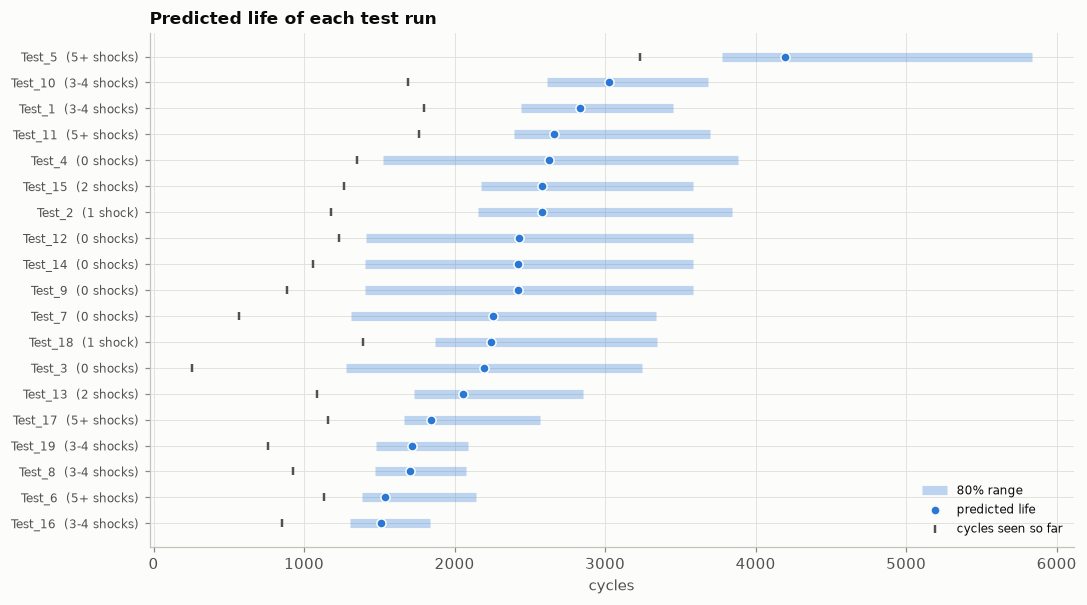

In [12]:
fig, ax = plt.subplots(figsize=(10, 5.6))
order = T.sort_values("final").index
y = np.arange(len(order))
ax.hlines(y, T.loc[order, "low"], T.loc[order, "high"], color=ps.BLUE, alpha=0.3, lw=6, label="80% range")
ax.scatter(T.loc[order, "final"], y, s=36, color=ps.BLUE, zorder=3, edgecolor=ps.SURFACE, linewidth=1, label="predicted life")
ax.scatter(T.loc[order, "t"], y, s=30, color=ps.INK2, marker="|", zorder=3, label="cycles seen so far")
ax.set_yticks(y); ax.set_yticklabels([f"Test_{r}  ({T.stage[r]})" for r in order], fontsize=8)
ax.set_xlabel("cycles"); ax.set_title("Predicted life of each test run"); ax.legend(fontsize=8, loc="lower right")
fig.tight_layout(); fig.savefig(FIG / "12_test_predictions.png"); plt.show()

**Reading the predictions**

- Predicted lives range from about 1,500 to 4,200 cycles.
- The six runs with no shock yet (`Test_3`, `Test_4`, `Test_7`, `Test_9`, `Test_12`, `Test_14`) all receive a typical life of 2,200 to 2,600 cycles with the widest ranges. These are the predictions most likely to be wrong.
- The tightest predictions are for runs with three or more shocks and a clear pace, such as `Test_8`, `Test_16` and `Test_19`.


## 2.9 Submission file

The submission needs one row per test measurement file: test id and RUL, semicolon-separated, no header. RUL follows the organisers' convention found in notebook 1: files are paired from the end of the run.

In [13]:
def write_submission(life_by_run, path):
    parts = []
    for r in sorted(test.run.unique()):
        n_files = int((test.run == r).sum())
        i = np.arange(n_files)
        rul = np.ceil((2 * life_by_run[r] - i) / 2).astype(int)
        parts.append(pd.DataFrame({"test": r, "rul": rul}))
    sub = pd.concat(parts, ignore_index=True)
    sub.to_csv(path, sep=";", header=False, index=False)
    return sub

sub = write_submission(T.final.round(), RES / "submission.csv")
sub_s = write_submission(T.final_session.round(), RES / "submission_session_features.csv")
T[["stage", "t", "hi_now", "n_shocks", "prior", "gbm", "final", "low", "high", "final_session"]].round(1).to_csv(RES / "test_predictions.csv")
E[["run", "t", "life", "stage", "test_like", "hi_now"] + list(loro.columns)].round(1).to_csv(RES / "loro_predictions.csv", index=False)

# checks against the rejection reasons on the leaderboard
files_per_test = test.groupby("run").size()
assert len(sub) == len(test) == 47187
assert (sub.groupby("test").size() == files_per_test).all(), "row count mismatch"
assert sub.test.nunique() == 19 and sub.rul.min() >= 1
assert (sub.groupby("test").rul.apply(lambda s: (s.diff().dropna() <= 0).all())).all(), "RUL must not increase"
print(f"submission.csv: {len(sub):,} rows, {sub.test.nunique()} tests, RUL from {sub.rul.min()} to {sub.rul.max()}")
print(sub.head(4).to_csv(sep=";", header=False, index=False))

submission.csv: 47,187 rows, 19 tests, RUL from 409 to 4197
1;2835
1;2835
1;2834
1;2834



## 2.10 Conclusions

**What was built**

- A training set of 4,436 cut-off examples from 46 runs, with features that describe only the degradation staircase.
- Two baselines and two models, compared by leave-one-run-out.
- A final model (survival prior before the first shock, gradient boosting after it), prediction ranges by stage, and a validated submission file.

**What was learned**

1. Remaining life becomes predictable once degradation starts: 58% of predictions within 20% after one shock, about three in four after two, and nine in ten after five.
2. Before the first shock, a sophisticated model is no better than the median of comparable past runs on the challenge metric, and every method is right less than half the time.
3. Obvious physics applied naively (extrapolating the shock rate) is worse than a blind guess early on. The value of the model is in correcting a known bias, not in finding hidden signal.
4. Early-cycle sensor features looked like an early warning and did not survive a significance check. With 46 runs, an apparent gain of nine percentage points can be noise, and it has to be tested before it is believed.

**Limitations**

- 46 independent runs is a small sample. Stage-level numbers, especially for the 1-shock and 2-shock stages, carry real uncertainty.
- The challenge score is computed with a local reading of an ambiguous formula. It ranks models; it does not predict the leaderboard value.
- The data is semi-synthetic: real hardware, but degradation injected by a script on a random schedule. The conclusion that the plateau carries no warning is a statement about this test bench. A real door wearing out might well show precursors in current or temperature.
- Model choice per stage used the same cross-validation that reports the scores.
- Every result depends on the shock detector. Its thresholds (3 units, 5 cycles) were set from the structure of the data, not tuned on model accuracy, and a first version that was too sensitive had to be corrected (notebook 1, section 1.4).

**Next steps**

- Upload `results/submission.csv` and compare the leaderboard score with the 0.65 expected here. The gap will show how close the local reading of the scoring formula is to the official one.
- `results/submission_session_features.csv` can be uploaded afterwards as an experiment on the session hypothesis.